# Proyecto

In [3]:
import numpy as np
from numpy.random import randint
import matplotlib.pyplot as plt
from scipy.fftpack import fft
import powerlaw
from scipy.stats import linregress

# Simulación 20x20

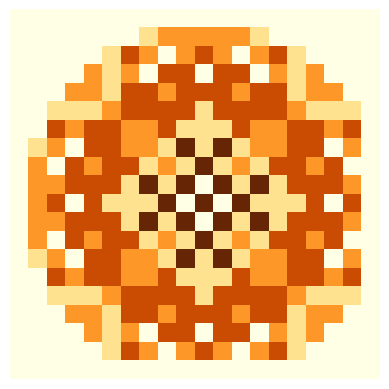

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib as mpl

mpl.rcParams['animation.embed_limit'] = 500 
# Definir el tamaño de la mesa de arena
N = 20
sand_desk = np.zeros((N, N), dtype=int)  # Inicializa con ceros
sand_grains = 600
#100000 # Número total de granos de arena

# Función para distribuir los granos entre celdas vecinas
def younglings_piles(position, sand_desk):
    x, y = position
    neighbors = [x, x, x-1, x+1], [y-1, y+1, y, y]
    sand_desk[neighbors] += 1
    
# Función para que se saque la arena alv
def off_desk(sand_desk):
    sand_desk[0, :] = 0
    sand_desk[:, 0] = 0
    sand_desk[-1, :] = 0
    sand_desk[:, -1] = 0

avalanches_duration = []
avalanche_size = []
time_series = []
current_avalanche_duration = 0
current_avalanche_size = 0
verify_end = 1

# Función de actualización para la animación
def actualizar(i):
    global sand_desk, current_avalanche_duration, verify_end, avalanches_duration, time_series, current_avalanche_size
    # Añadir un granito de arena a una posición aleatoria
    #position = np.random.randint(N), np.random.randint(N)
    position = 10, 10 # Contruir pila de arena simétrica con un punto fijo
    sand_desk[position] += 1
    
    # Identificar pilas que necesitan "avalancha" (pasan el límite de 4 granos)
    parent_piles = np.argwhere(sand_desk >= 4)
    len_parent = len(parent_piles)
    time_series.append(len_parent)
    if len(parent_piles) != 0:
        current_avalanche_duration += 1 # Cada que se desencadena un evento, se cuenta un tiempo
        current_avalanche_size += len_parent # Registrar todos los parent piles
        
        indexing_parents = parent_piles.T # Transposición para que se pueda indexar por dimensión(x,y)
        sand_desk[indexing_parents[0], indexing_parents[1]] -= 4 # Quitarle arena a la pila inestable
        np.apply_along_axis(younglings_piles, 1, parent_piles, sand_desk) # Donar arenita a sus hijitos juju
    
    if current_avalanche_duration == verify_end: # Si entra continuamente al condicional anterior, el verificador lo seguirá
        verify_end += 1
    elif verify_end > current_avalanche_duration and verify_end > 1: # Si el verificador es mayor, entonces no hubo más eventos
        avalanches_duration.append(current_avalanche_duration) # Entonces registramos el tiempo de la avalancha 
        avalanche_size.append(current_avalanche_size) # Resgistramos el tamaño de la avalancha
        
        current_avalanche_duration = 0
        verify_end = 1
        
    off_desk(sand_desk)  # Eliminar la arena que se sale de la mesa
    mat.set_data(sand_desk)  # Actualiza la visualización
    return [mat]

# Matriz de animación
fig, ax = plt.subplots()
mat = ax.matshow(sand_desk, cmap='YlOrBr', vmin=0, vmax=4)
ax.axis('off')  

# Generar la animación y reproducirla con html 
ani = animation.FuncAnimation(fig, actualizar, frames=sand_grains, interval=20, blit=True)
ani.save("abelian_fractal_20x20.mp4", writer="ffmpeg", fps=20)
#HTML(ani.to_jshtml())


# Simulación 50x50

KeyboardInterrupt: 

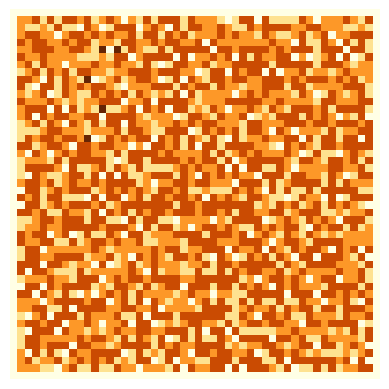

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib as mpl

mpl.rcParams['animation.embed_limit'] = 1000 
# Definir el tamaño de la mesa de arena
N = 50
sand_desk = np.zeros((N, N), dtype=int)  # Inicializa con ceros
sand_grains = 100000 # Número total de granos de arena

# Función para distribuir los granos entre celdas vecinas
def younglings_piles(position, sand_desk):
    x, y = position
    neighbors = [x, x, x-1, x+1], [y-1, y+1, y, y]
    sand_desk[neighbors] += 1
    
# Función para que se saque la arena alv
def off_desk(sand_desk):
    sand_desk[0, :] = 0
    sand_desk[:, 0] = 0
    sand_desk[-1, :] = 0
    sand_desk[:, -1] = 0

avalanches_duration = []
avalanche_size = []
time_series = []
current_avalanche_duration = 0
current_avalanche_size = 0
verify_end = 1
event = False

# Función de actualización para la animación
def actualizar(i):
    global sand_desk, current_avalanche_duration, verify_end, avalanches_duration, time_series, event, current_avalanche_size, avalanche_size
    if not event:
        position = np.random.randint(N), np.random.randint(N) # Añadir un granito de arena a una posición aleatoria
        #position = 10, 10 # Contruir pila de arena simétrica con un punto fijo
        sand_desk[position] += 1
    
    parent_piles = np.argwhere(sand_desk >= 4) # Identificar pilas que necesitan "avalancha" (pasan el límite de 4 granos)
    len_parent = len(parent_piles)
    time_series.append(len_parent)

    if len(parent_piles) != 0:
        current_avalanche_duration += 1 # Cada que se desencadena un evento, se cuenta un tiempo
        current_avalanche_size += len_parent # Registrar todos los parent piles
        
        indexing_parents = parent_piles.T # Transposición para que se pueda indexar por dimensión(x,y)
        sand_desk[indexing_parents[0], indexing_parents[1]] -= 4 # Quitarle arena a la pila inestable
        np.apply_along_axis(younglings_piles, 1, parent_piles, sand_desk) # Donar arenita a sus hijitos juju
    
    if current_avalanche_duration == verify_end: # Si entra continuamente al condicional anterior, el verificador lo seguirá
        verify_end += 1
        event = True
    elif verify_end > current_avalanche_duration and verify_end > 1: # Si el verificador es mayor, entonces no hubo más eventos
        avalanches_duration.append(current_avalanche_duration) # Entonces registramos el tiempo de la avalancha 
        avalanche_size.append(current_avalanche_size) # Resgistramos el tamaño de la avalancha
        
        current_avalanche_duration = 0
        current_avalanche_size = 0
        verify_end = 1
        event = False
        
    off_desk(sand_desk)  # Eliminar la arena que se sale de la mesa
    mat.set_data(sand_desk)  # Actualiza la visualización
    return [mat]

# Matriz de animación
fig, ax = plt.subplots()
mat = ax.matshow(sand_desk, cmap='YlOrBr', vmin=0, vmax=4)
ax.axis('off')  

# Generar la animación y reproducirla con html 
ani = animation.FuncAnimation(fig, actualizar, frames=sand_grains, interval=20, blit=True)
HTML(ani.to_jshtml())
#ani.save("sand_animation.mp4", writer="ffmpeg", fps=20)

In [41]:
import numpy as np

# Definir el tamaño de la mesa de arena
N = 50
sand_desk = np.zeros((N, N), dtype=int)  # Inicializa con ceros
sand_grains = 1000000  # Número total de granos de arena

# Función para distribuir los granos entre celdas vecinas
def younglings_piles(position, sand_desk):
    x, y = position
    neighbors = [x, x, x - 1, x + 1], [y - 1, y + 1, y, y]
    sand_desk[neighbors] += 1

# Función para eliminar la arena que se sale de la mesa
def off_desk(sand_desk):
    sand_desk[0, :] = 0
    sand_desk[:, 0] = 0
    sand_desk[-1, :] = 0
    sand_desk[:, -1] = 0

# Variables para registrar eventos y resultados
avalanches_duration = []
avalanche_size = []
time_series = []
current_avalanche_duration = 0
current_avalanche_size = 0
verify_end = 1
event = False

# Simulación de la dinámica sin animación
for _ in range(sand_grains):
    if not event:
        position = np.random.randint(N), np.random.randint(N)  # Añadir un granito de arena a una posición aleatoria
        sand_desk[position] += 1
    
    parent_piles = np.argwhere(sand_desk >= 4)  # Identificar pilas inestables
    len_parent = len(parent_piles)
    time_series.append(len_parent)

    if len(parent_piles) != 0:
        current_avalanche_duration += 1  # Registrar duración de la avalancha
        current_avalanche_size += len_parent  # Registrar tamaño de la avalancha

        indexing_parents = parent_piles.T  # Transposición para indexación
        sand_desk[indexing_parents[0], indexing_parents[1]] -= 4  # Quitar arena de pilas inestables
        np.apply_along_axis(younglings_piles, 1, parent_piles, sand_desk)  # Redistribuir arena

    if current_avalanche_duration == verify_end:  # Verificar si continúan eventos
        verify_end += 1
        event = True
    elif verify_end > current_avalanche_duration and verify_end > 1:  # Registrar evento si no hay más actividad
        avalanches_duration.append(current_avalanche_duration)
        avalanche_size.append(current_avalanche_size)
        current_avalanche_duration = 0
        current_avalanche_size = 0
        verify_end = 1
        event = False

    off_desk(sand_desk)  # Eliminar arena que se sale de la mes

In [71]:
ani.save("sand_animation.mp4", writer="ffmpeg", fps=20)

python(58760) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


# Tamaños de avalanchas

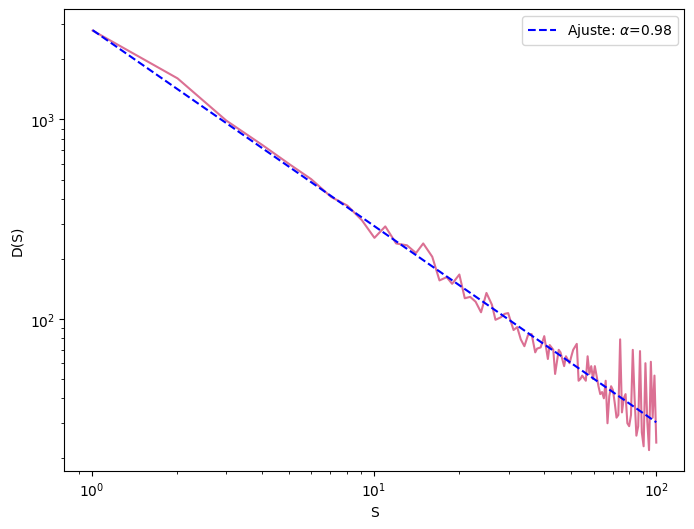

In [ ]:
data = avalanche_size[10000:]

# Crear bins en escala logarítmica
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 600)

# Construir el histograma con bins logarítmicos
dt, t_edges = np.histogram(data, bins=bins)

# Calcular el punto medio de los bins
t = 0.5 * (t_edges[1:] + t_edges[:-1])
#print(dt)
limit = t < 1e2
t = t[limit]
dt = dt[limit]
# Filtrar ceros para evitar problemas en log-log
nozero = dt != 0
dt = dt[nozero]
t = t[nozero]

# Regresión lineal en log-log
log_t = np.log(t)
log_dt = np.log(dt)
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
alpha = -slope  # Exponente de la ley de potencia
C = np.exp(intercept)  # Constante de escala

# Generar línea ajustada
fit_line = C * t**(-alpha)

plt.figure(figsize=(8, 6))
plt.loglog(t, dt, color = 'palevioletred')
plt.loglog(t, fit_line, "b--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
plt.xlabel('S')
plt.ylabel('D(S)')
#plt.title('FIG. 5. Cluster size distribution')
plt.legend()
plt.show()

# Tiempos de vida

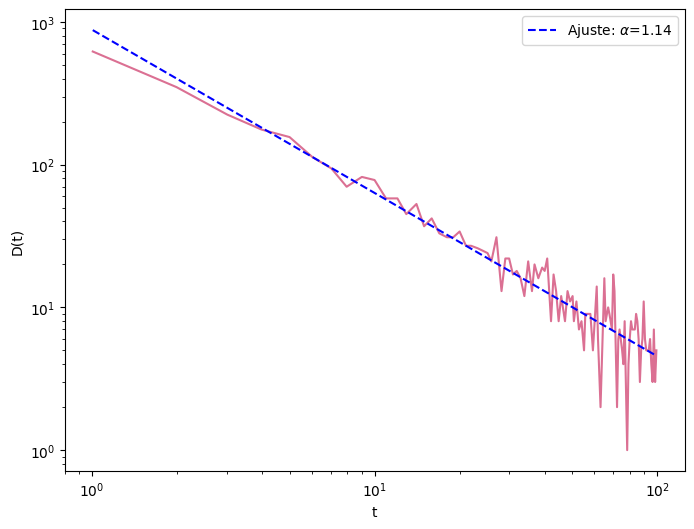

In [ ]:
data = avalanches_duration[10000:]

# Crear bins en escala logarítmica
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 600)

# Construir el histograma con bins logarítmicos
dt, t_edges = np.histogram(data, bins=bins)

# Calcular el punto medio de los bins
t = 0.5 * (t_edges[1:] + t_edges[:-1])
#print(dt)
limit = t < 1e2
t = t[limit]
dt = dt[limit]
# Filtrar ceros para evitar problemas en log-log
nozero = dt != 0
dt = dt[nozero]
t = t[nozero]

# Regresión lineal en log-log
log_t = np.log(t)
log_dt = np.log(dt)
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
alpha = -slope  # Exponente de la ley de potencia
C = np.exp(intercept)  # Constante de escala

# Generar línea ajustada
fit_line = C * t**(-alpha)


plt.figure(figsize=(8, 6))
plt.loglog(t, dt, color = 'palevioletred')
plt.loglog(t, fit_line, "b--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
plt.xlabel('t')
plt.ylabel('D(t)')
#plt.title('FIG. 4. Distribution of lifetimes ')
plt.legend()
plt.show()


# Espectro de potencias

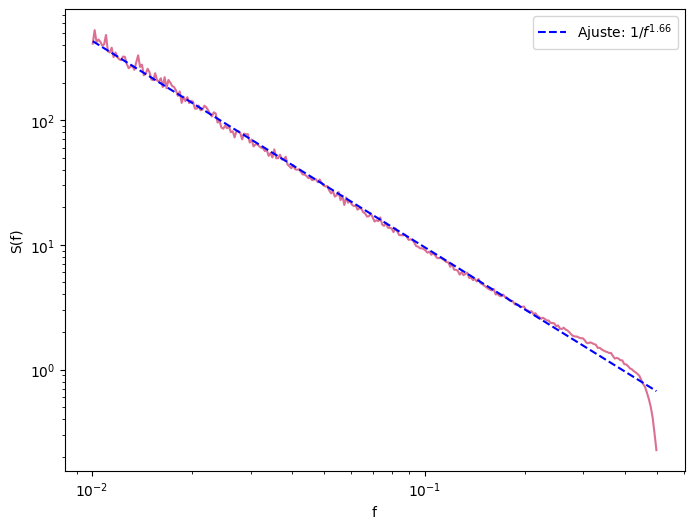

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy.stats import linregress
fs = 1
psds =  np.abs(fft(time_series[1000:])) ** 2 / len(time_series[1000:])
N = len(psds)
psds_positive = psds[:(N//2)]
frequencies = np.fft.fftfreq(N, 1/fs)[:N // 2]

low_freq = 0.01  # Frecuencia mínima
mask = frequencies >= low_freq
frequencies = frequencies[mask]
psds_positive = psds_positive[mask]

# Crear bins logarítmicos
bins = np.logspace(np.log10(frequencies.min()), np.log10(frequencies.max()), num=300)
bin_indices = np.digitize(frequencies, bins)

# Promediar en cada bin
psds_binned = [psds_positive[bin_indices == i].mean() for i in range(1, len(bins))]
frequencies_binned = [frequencies[bin_indices == i].mean() for i in range(1, len(bins))]

# Log-transformar los datos
log_frequencies = np.log(frequencies_binned)
log_psds = np.log(psds_binned)

# Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(log_frequencies, log_psds)
beta = -slope  # El exponente de la ley de potencia es la pendiente negativa
C = np.exp(intercept)
# Generar línea ajustada
fit_line = C * frequencies_binned**(-beta)


plt.figure(figsize=(8, 6))
plt.loglog(frequencies_binned, psds_binned, color='palevioletred')
plt.loglog(frequencies_binned, fit_line, 'b--', label=f'Ajuste: $1/f^{{{beta:.2f}}}$')

#plt.title('FIG. 7. Power spectrum of the function F(t)')
plt.ylabel('S(f)')
plt.xlabel('f')
plt.legend()
#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


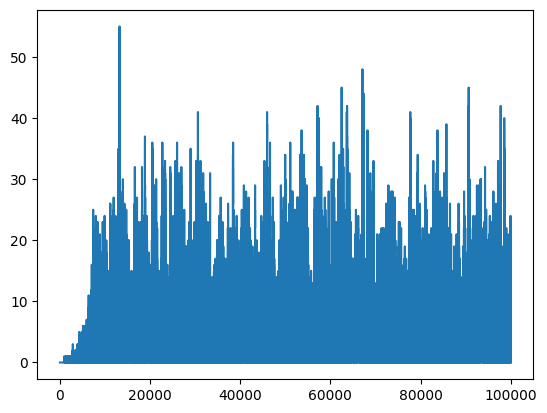

In [131]:
plt.plot(time_series)

# Simulación 3D: 20x20x20

In [1]:
import numpy as np

# Dimensiones de la mesa de arena
N = 20
sand_desk = np.zeros((N, N, N), dtype=int)
sand_grains = 1000000

# Función para distribuir los granos entre celdas vecinas
def younglings_piles_closed(position, sand_desk):
    x, y, z = position
    N = sand_desk.shape[0]
    neighbors = [
        (x-1, y, z), (x+1, y, z),
        (x, y-1, z), (x, y+1, z),
        (x, y, z-1), (x, y, z+1)
    ]
    for nx, ny, nz in neighbors:
        if 0 <= nx < N and 0 <= ny < N and 0 <= nz < N:
            sand_desk[nx, ny, nz] += 1

# Variables para registrar las avalanchas
avalanches_duration = []
avalanche_size = []
time_series = []

current_avalanche_duration = 0
current_avalanche_size = 0
event = False

# Simulación principal
for grain in range(sand_grains):
    if not event:
        position = tuple(np.random.randint(N, size=3))
        sand_desk[position] += 1

    parent_piles = np.argwhere(sand_desk >= 6)
    len_parent = len(parent_piles)
    if len_parent > 0:
        time_series.append(len_parent)
        current_avalanche_duration += 1
        current_avalanche_size += len_parent
        
        indexing_parents = parent_piles.T # Transposición para que se pueda indexar por dimensión(x,y)
        sand_desk[indexing_parents[0], indexing_parents[1], indexing_parents[2]] -= 6 # Quitarle arena a la pila inestable
        for position in parent_piles:
            younglings_piles_closed(position, sand_desk)
    else:
        if current_avalanche_duration > 0:
            avalanches_duration.append(current_avalanche_duration)
            avalanche_size.append(current_avalanche_size)
            current_avalanche_duration = 0
            current_avalanche_size = 0
        event = False


# Tiempos de vida

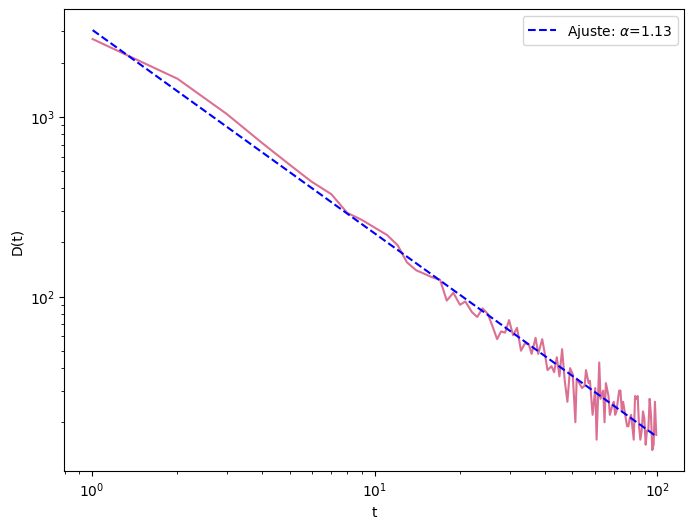

In [ ]:
data = avalanches_duration[10000:]

# Crear bins en escala logarítmica
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 600)

# Construir el histograma con bins logarítmicos
dt, t_edges = np.histogram(data, bins=bins)

# Calcular el punto medio de los bins
t = 0.5 * (t_edges[1:] + t_edges[:-1])
#print(dt)
limit = t < 1e2
t = t[limit]
dt = dt[limit]
# Filtrar ceros para evitar problemas en log-log
nozero = dt != 0
dt = dt[nozero]
t = t[nozero]

# Regresión lineal en log-log
log_t = np.log(t)
log_dt = np.log(dt)
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
alpha = -slope  # Exponente de la ley de potencia
C = np.exp(intercept)  # Constante de escala

# Generar línea ajustada
fit_line = C * t**(-alpha)


plt.figure(figsize=(8, 6))
plt.loglog(t, dt, color = 'palevioletred')
plt.loglog(t, fit_line, "b--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
plt.xlabel('t')
plt.ylabel('D(t)')
#plt.title('FIG. 4. Distribution of lifetimes ')
plt.legend()
plt.show()

# Tamaños de avalancha

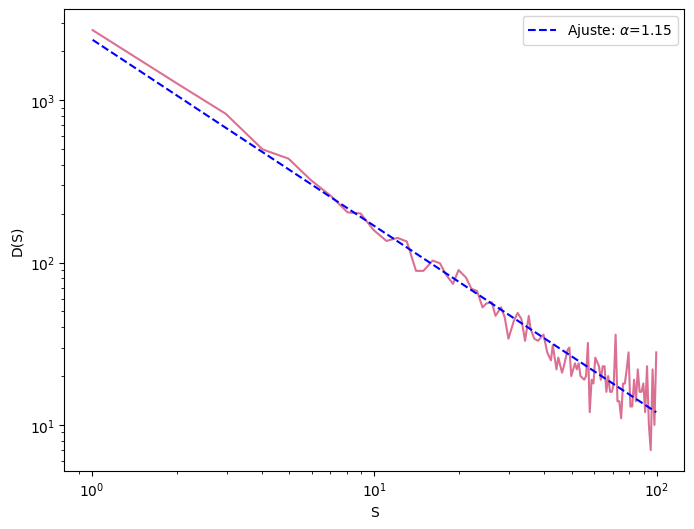

In [ ]:
data = avalanche_size[10000:]

# Crear bins en escala logarítmica
bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 600)

# Construir el histograma con bins logarítmicos
dt, t_edges = np.histogram(data, bins=bins)

# Calcular el punto medio de los bins
t = 0.5 * (t_edges[1:] + t_edges[:-1])
#print(dt)
limit = t < 1e2
t = t[limit]
dt = dt[limit]
# Filtrar ceros para evitar problemas en log-log
nozero = dt != 0
dt = dt[nozero]
t = t[nozero]

# Regresión lineal en log-log
log_t = np.log(t)
log_dt = np.log(dt)
slope, intercept, r_value, p_value, std_err = linregress(log_t, log_dt)
alpha = -slope  # Exponente de la ley de potencia
C = np.exp(intercept)  # Constante de escala
# Generar línea ajustada
fit_line = C * t**(-alpha)

plt.figure(figsize=(8, 6))
plt.loglog(t, dt, color = 'palevioletred')
plt.loglog(t, fit_line, "b--", label=f'Ajuste: $ \\alpha $={alpha:.2f}')
plt.xlabel('S')
plt.ylabel('D(S)')
#plt.title('FIG. 5. Cluster size distribution')
plt.legend()
plt.show()

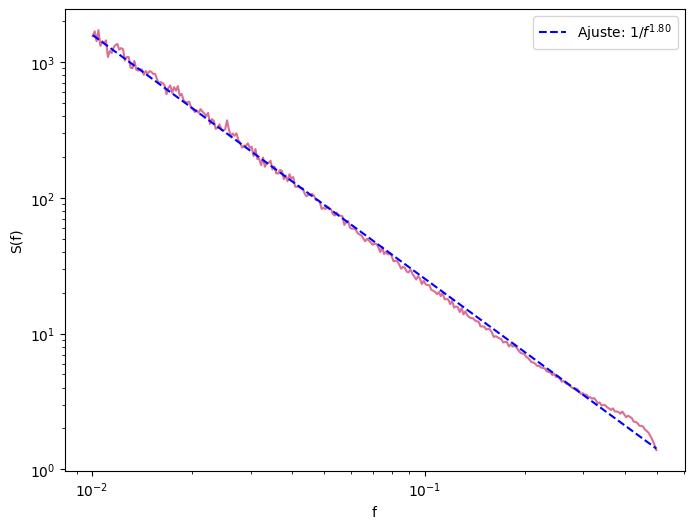

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft
from scipy.stats import linregress
fs = 1
psds =  np.abs(fft(time_series[1000:])) ** 2 / len(time_series[1000:])
N = len(psds)
psds_positive = psds[:(N//2)]
frequencies = np.fft.fftfreq(N, 1/fs)[:N // 2]

low_freq = 0.01  # Frecuencia mínima
mask = frequencies >= low_freq
frequencies = frequencies[mask]
psds_positive = psds_positive[mask]

# Crear bins logarítmicos
bins = np.logspace(np.log10(frequencies.min()), np.log10(frequencies.max()), num=300)
bin_indices = np.digitize(frequencies, bins)

# Promediar en cada bin
psds_binned = [psds_positive[bin_indices == i].mean() for i in range(1, len(bins))]
frequencies_binned = [frequencies[bin_indices == i].mean() for i in range(1, len(bins))]

# Log-transformar los datos
log_frequencies = np.log(frequencies_binned)
log_psds = np.log(psds_binned)

# Ajuste lineal
slope, intercept, r_value, p_value, std_err = linregress(log_frequencies, log_psds)
beta = -slope  # El exponente de la ley de potencia es la pendiente negativa
C = np.exp(intercept)
# Generar línea ajustada
fit_line = C * frequencies_binned**(-beta)


plt.figure(figsize=(8, 6))
plt.loglog(frequencies_binned, psds_binned, color='palevioletred')
plt.loglog(frequencies_binned, fit_line, 'b--', label=f'Ajuste: $1/f^{{{beta:.2f}}}$')

#plt.title('FIG. 7. Power spectrum of the function F(t)')
plt.ylabel('S(f)')
plt.xlabel('f')
plt.legend()
#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


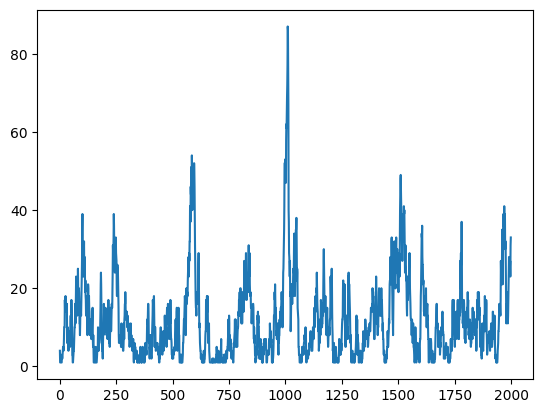

In [7]:
plt.plot(time_series[30000:32000])